--- Dataset Preview ---
     WBC   RBC    HGB   MCV   MCH     PLT  Sickling_Test
0   6.31  4.67  10.99  85.0  31.0  173093              1
1  10.63  4.84  10.66  92.4  25.0  165188              1
2   8.99  5.68   9.41  86.9  26.8  301048              1
3   7.99  4.55  12.86  72.5  30.3  391529              1
4   4.67  5.71  11.81  75.6  28.3  275680              1

--- Dataset Statistics ---
               WBC          RBC          HGB          MCV          MCH  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean      7.226200     4.881256    12.010968    85.231040    28.596560   
std       2.172318     0.628339     2.326118     8.634632     3.176231   
min       3.500000     3.800000     8.000000    70.000000    23.000000   
25%       5.330000     4.340000     9.980000    77.900000    25.800000   
50%       7.250000     4.870000    11.970000    85.400000    28.600000   
75%       9.110000     5.410000    14.082500    92.500000    31.300000   
max      11.00

C:\Users\Dell\AppData\Local\Temp\ipykernel_8616\1925683804.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sickling_Test', data=df, palette='viridis')


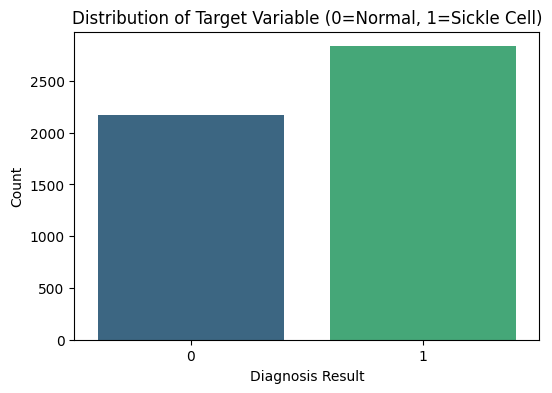

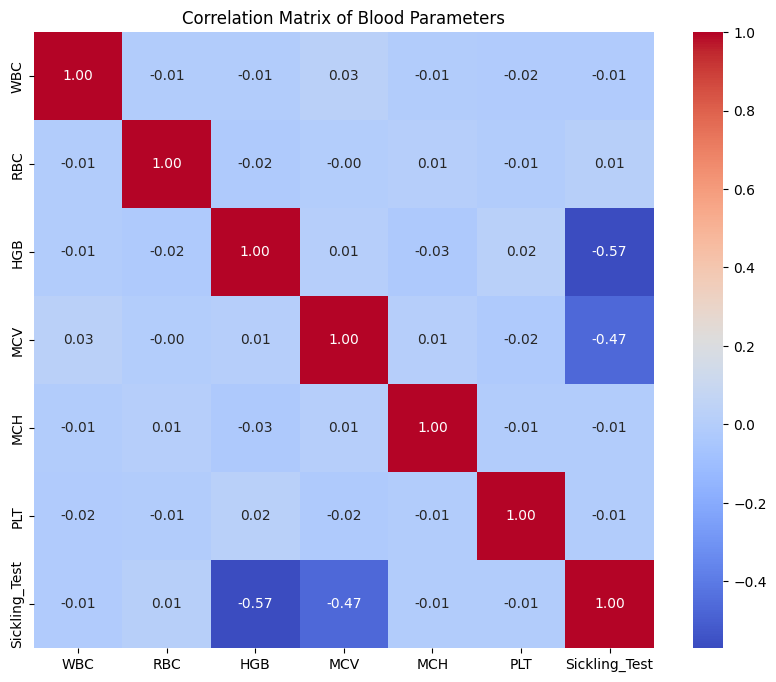


Training Shape: (4000, 6)
Testing Shape: (1000, 6)

Model Training Completed!

Model Accuracy: 100.00%

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       452
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



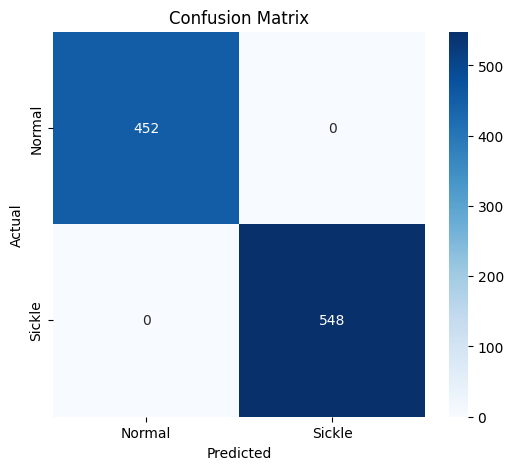

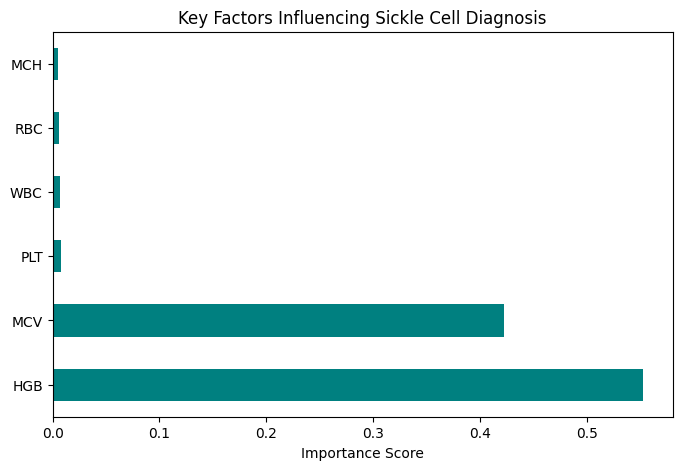


--- Live Test Example ---
Prediction Result: POSITIVE: High probability of Sickle Cell Disease.


d:\SCD_PROJECT\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# STEP 1: Load the Data
# ==========================================
# Reading the file you provided
df = pd.read_csv('sickle_dataset_5000.csv')

print("--- Dataset Preview ---")
print(df.head())

print("\n--- Dataset Statistics ---")
print(df.describe())

# ==========================================
# STEP 2: Data Visualization (EDA)
# ==========================================
# 1. Count Plot: Check if data is balanced (Normal vs Sickle)
plt.figure(figsize=(6, 4))
sns.countplot(x='Sickling_Test', data=df, palette='viridis')
plt.title('Distribution of Target Variable (0=Normal, 1=Sickle Cell)')
plt.xlabel('Diagnosis Result')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap: See which blood factors relate to each other
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Blood Parameters')
plt.show()

# ==========================================
# STEP 3: Data Preprocessing
# ==========================================
# Separate Features (X) and Target (y)
X = df.drop('Sickling_Test', axis=1)  # All columns except the result
y = df['Sickling_Test']               # Only the result column

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

# ==========================================
# STEP 4: Model Training
# ==========================================
# We use Random Forest because it is highly accurate for clinical data
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ==========================================
# STEP 5: Model Evaluation
# ==========================================
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc * 100:.2f}%")

# Detailed Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Sickle'], yticklabels=['Normal', 'Sickle'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



# ==========================================
# STEP 6: Feature Importance (Why did the model predict that?)
# ==========================================
# This shows which blood test was most important for the diagnosis
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 5))
feature_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Key Factors Influencing Sickle Cell Diagnosis')
plt.xlabel('Importance Score')
plt.show()

# ==========================================
# STEP 7: Testing System
# ==========================================
def predict_sickle_cell(wbc, rbc, hgb, mcv, mch, plt_count):
    """
    Function to accept raw patient data and return a diagnosis
    """
    patient_data = np.array([[wbc, rbc, hgb, mcv, mch, plt_count]])
    prediction = model.predict(patient_data)
    
    if prediction[0] == 1:
        return "POSITIVE: High probability of Sickle Cell Disease."
    else:
        return "NEGATIVE: Patient appears healthy."

# Example Test
print("\n--- Live Test Example ---")
# Let's test with random values (e.g., Low HGB, Normal RBC)
result = predict_sickle_cell(wbc=7.5, rbc=4.1, hgb=9.2, mcv=88, mch=28, plt_count=250000)
print(f"Prediction Result: {result}")